In [72]:
# Import libraries
from ipydatagrid import DataGrid
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #Adjusts the configuration of the plots we will create

The goal of this project is to build a dashboard focused on Customer Retention and Lifetime Value. For this purpose, we will clean the data and perform feature engineering at a row-level granularity, leveraging Python and libraries such as Pandas and Seaborn. Further aggregations will be offloaded to our BI tool, Tableau.

In [73]:
# Read the data. Reading ORDERNUMBER as object to preserve potential lines starting with a zero.
df = pd.read_csv('sales_data_sample.csv', encoding='CP865', dtype={'ORDERNUMBER': str})

In [74]:
# Looking at the data
pd.set_option('display.max_columns', None)
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [75]:
# Looking at the data
df.describe()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [76]:
# Looking at the data
df.describe(include='object')

,ORDERNUMBER,ORDERDATE,STATUS,PRODUCTLINE,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823,2823,2823,2823,2823,2823,2823,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,307,252,6,7,109,92,91,92,9,73,16,73,19,3,77,72,3
top,10332,11/14/2003 0:00,Shipped,Classic Cars,S18_3232,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,18,38,2617,967,52,259,259,259,55,304,416,259,1004,1407,259,259,1384


At first glance, we tend to sell products below the MSRP, specially the most expensive ones. We sell in bulk. Our most frequent customer is in Madrid, and our most successful product line is Classic Cars. Apparently, there's only missing data in some categorical columns. Let's corroborate.

In [77]:
# Missing data columns
for col in df.columns:
    pct_missing = np.mean(df[col].isnull()) * 100
    if pct_missing > 0:
        print(f'{col} - {pct_missing:.2f}%')

ADDRESSLINE2 - 89.30%
STATE - 52.64%
POSTALCODE - 2.69%
TERRITORY - 38.04%


ADRESSLINE2 missing values are not a problem, it is a specification not always needed.
Countries of Europe, Asia and Africa divide their territory on provinces or regions, so the STATES missing values may be because of that. 
To get the missing POSTALCODE values we could contact the client, as there are little missing, it's not a problem. 
After checking the original data source, TERRITORY missing values appear to be a reading error, the encoding detects NA as a missing value when it means North America. 

In [78]:
# Ensuring TERRITORY missing values correspond to North America
df['TERRITORY'] = df['TERRITORY'].replace(np.nan, 'MISSING')
territory_missing_values = df.groupby(['TERRITORY', 'COUNTRY']).size()
print(territory_missing_values)

TERRITORY  COUNTRY    
APAC       Australia       185
           Singapore        36
EMEA       Austria          55
           Belgium          33
           Denmark          63
                          ... 
Japan      Japan            52
           Philippines      26
           Singapore        43
MISSING    Canada           70
           USA            1004
Length: 20, dtype: int64


Being the case, MISSING is replaced by NA

In [79]:
# Replacing MISSING with NA - TERRITORY column
df['TERRITORY'] = df['TERRITORY'].replace('MISSING', 'NA')

In [80]:
# Ensuring STATE missing values belong to countries
df['STATE'] = df['STATE'].replace(np.nan, 'MISSING') 
state_missing_values = df.groupby(['TERRITORY', 'STATE']).size()
state_missing_values

TERRITORY  STATE        
APAC       MISSING           36
           NSW               92
           Queensland        15
           Victoria          78
EMEA       Isle of Wight     26
                           ... 
NA         NJ                21
           NV                29
           NY               178
           PA                75
           Quebec            22
Length: 19, dtype: int64

All regions with missing values in STATE include countries that don't divide in States. Now, we must be certain the data type of each column is appropiate.

In [81]:
df.dtypes

ORDERNUMBER          object
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
                     ...   
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
Length: 25, dtype: object

Most columns have the correct data type, so we'll just make two changes. ORDERNUMBER is read as an integer, in this particular case it's not a problem, but sometimes ordernumbers and similar identifiers begin with one or more zeros. In such a case, reading the column as integer will ignore those zeroes, affecting trazability. Preventing this, we will modify the reading format. Also, ORDERDATE should have a datetime data type to enable the manipulation of dates. 

In [82]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], format='%m/%d/%Y %H:%M')
df.dtypes

ORDERNUMBER          object
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
                     ...   
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
Length: 25, dtype: object

Finally, we want to know if there are duplicate rows. Initially, there are 2823 lines.

In [83]:
# Dropping duplicates
df_no_duplicates = df.drop_duplicates()
len(df)

2823

No duplicates, no need to investigate regarding this.

The next step is the Exploratory Analysis, knowing the data.

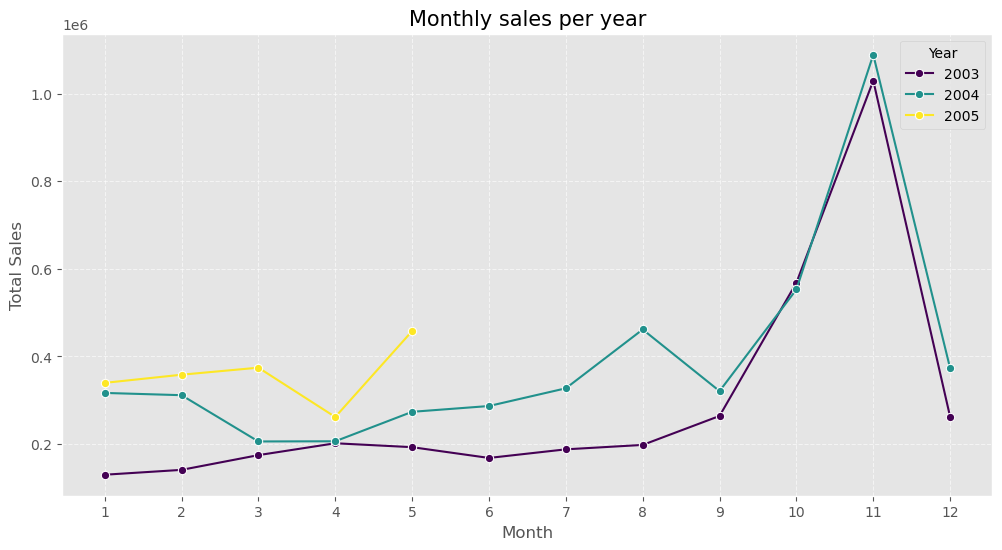

In [84]:
# Sales per month for each year
df_plot = df.groupby(['YEAR_ID', 'MONTH_ID'])['SALES'].sum().reset_index()
df_plot = df_plot.sort_values('MONTH_ID')

plt.figure(figsize=(12, 6))

# hue='YEAR_ID' makes a line for each year
# marker='o' for markers
sns.lineplot(data=df_plot, x='MONTH_ID', y='SALES', hue='YEAR_ID', marker='o', palette='viridis')

# Personalización del gráfico
plt.title('Monthly sales per year', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, 13)) # Months go from 1 to 12
plt.legend(title='Year')

plt.show()

Now, sales per product line

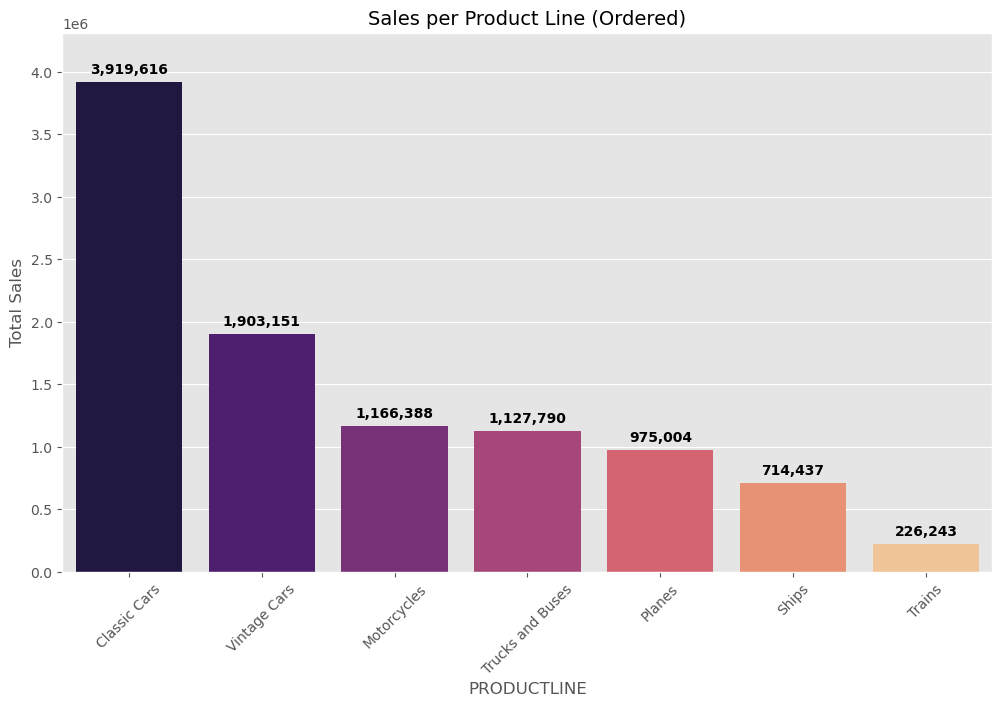

In [85]:
order_data = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))

# 2. Creamos el gráfico usando el orden calculado
ax = sns.barplot(
    data=order_data, 
    x='PRODUCTLINE', 
    y='SALES', 
    hue='PRODUCTLINE', 
    legend=False, 
    palette='magma'
)

# 3. Añadimos los números arriba de cada barra
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}', # Formato con comas para miles y sin decimales
        (p.get_x() + p.get_width() / 2., p.get_height()), # Posición
        ha='center', va='center', 
        xytext=(0, 9), # Desplazamiento hacia arriba (9 puntos)
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Sales per Product Line (Ordered)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Total Sales')

# Ajustamos el límite superior del eje Y para que los números no se corten
plt.ylim(0, order_data['SALES'].max() * 1.1)

plt.show()

Sales per Territory

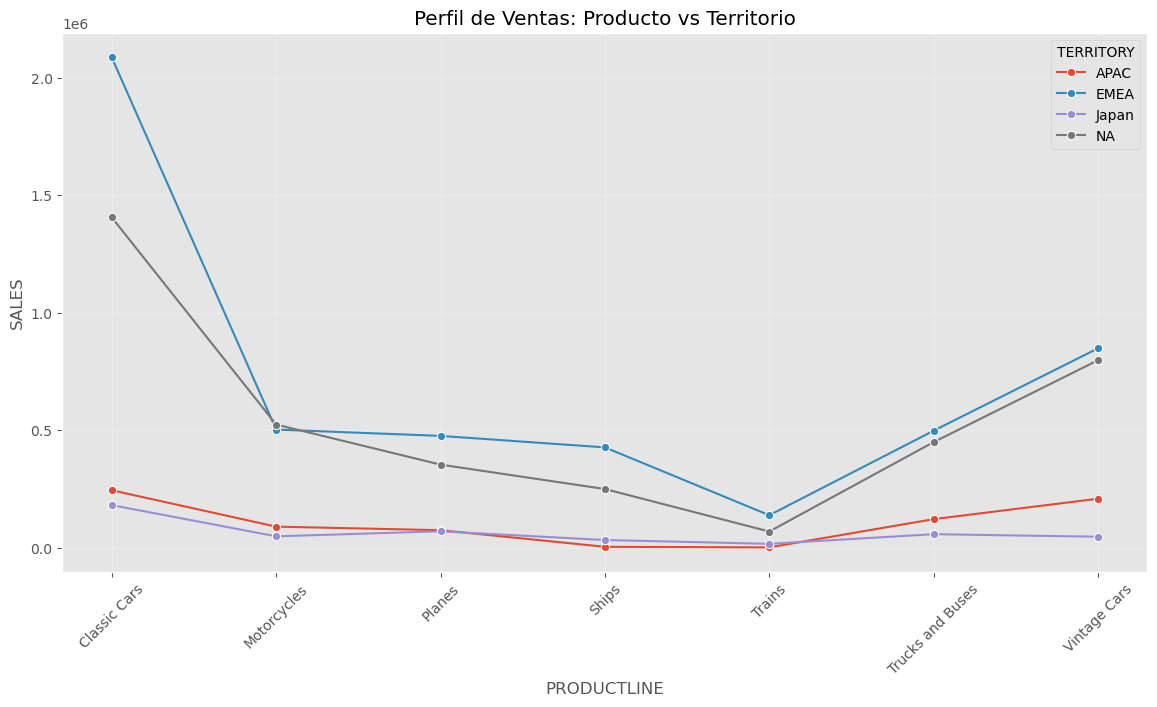

In [86]:
plt.figure(figsize=(14, 7))

# Agrupamos primero para que la línea sea limpia
df_line = df.groupby(['PRODUCTLINE', 'TERRITORY'])['SALES'].sum().reset_index()

# Dibujamos las líneas
sns.lineplot(data=df_line, x='PRODUCTLINE', y='SALES', hue='TERRITORY', marker='o')

plt.title('Perfil de Ventas: Producto vs Territorio')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [87]:
cancelled = df.groupby(['STATUS'])['ORDERNUMBER'].count().reset_index()
cancelled

,STATUS,ORDERNUMBER
0,Cancelled,60
1,Disputed,14
2,In Process,41
3,On Hold,44
4,Resolved,47
5,Shipped,2617


Now that we know the data better, we start the Cohort Analysis. The cohorts will be calculated in Tableau, however, the purchase status is easier to obtain in Python. New means the line represents the client's first purchase, returning means the purchase happened in the next 3 months after the previous one, and recovered means they bought after 90 days.

In [94]:
# Customer status will be determined with shipped orders. 
valid_statuses = ['Shipped', 'In Process', 'Resolved']
not_shipped_orders = df[~df['STATUS'].isin(valid_statuses)].copy()
not_shipped_orders['PURCHASE_STATUS'] = 'NON-ELIGIBLE'

df = df[df['STATUS'].isin(valid_statuses)].copy()

# Operating with the whole df, avoid cycles
df = df.sort_values(['CUSTOMERNAME', 'ORDERDATE']).reset_index(drop=True)
df['ORDER_SEQUENCE'] = (
    df.groupby('CUSTOMERNAME')['ORDERNUMBER']
      .transform(lambda x: pd.factorize(x)[0]) + 1
)

# Get the previous order date PER CUSTOMER
# By using groupby + shift, Pandas handles the "customer change" automatically.
# The first row of every customer will result in a NaN (None) here.
df['PREV_ORDER_DATE'] = df.groupby('CUSTOMERNAME')['ORDERDATE'].shift(1)

# Calculate the gap in days
df['DAYS_SINCE_LAST_PURCHASE'] = (df['ORDERDATE'] - df['PREV_ORDER_DATE']).dt.days

# Corroborate order numbers have only one date assigned
order_nr_date = df.groupby(['ORDERNUMBER'])['ORDERDATE'].nunique().sort_values(ascending=False)
print(order_nr_date[order_nr_date > 1])

Series([], Name: ORDERDATE, dtype: int64)


In [95]:
# Purchase status calculation
order_nr_days = df.groupby(['ORDERNUMBER', 'ORDER_SEQUENCE'])['DAYS_SINCE_LAST_PURCHASE'].sum().reset_index()
order_nr_days = order_nr_days.sort_values(by='DAYS_SINCE_LAST_PURCHASE',ascending=False)
conditions = [
    order_nr_days['DAYS_SINCE_LAST_PURCHASE'] >= 90,
    (order_nr_days['DAYS_SINCE_LAST_PURCHASE'] < 90) & (order_nr_days['DAYS_SINCE_LAST_PURCHASE'] >= 0) & (order_nr_days['ORDER_SEQUENCE'] != 1),
    order_nr_days['ORDER_SEQUENCE'] == 1
]
results = ['RECOVERED', 'RETURNING', 'NEW']

# Assigning Status to order numbers
order_nr_days['STATUS'] = np.select(conditions, results, default = 'UNKNOWN')

# Status to original df
status_dict = dict(zip(order_nr_days['ORDERNUMBER'], order_nr_days['STATUS']))
df['PURCHASE_STATUS'] = df['ORDERNUMBER'].map(status_dict)

# Cohort index
df['COHORT_INDEX'] = ((df['YEAR_ID'] - 2003) * 4) + df['QTR_ID']
df = pd.concat([df, not_shipped_orders]).reset_index(drop=True)

In [96]:
# Print data
df = df.drop(columns=['ORDER_SEQUENCE', 'PREV_ORDER_DATE'], errors='ignore')

datagrid = DataGrid(df, selection_mode="row", editable=False)
datagrid

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [97]:
df.to_csv("Sales_Data.csv", index = False)